<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/HR_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 1.482 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 2.958 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.242 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 1.578 detik


41666654166667500000

**Load Dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [23]:
data = pd.read_csv("/content/HR_comma_sep.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

print("\nPreview data after initial loading and duplicate handling:")
display(data.head())

Preview data:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Checking for missing values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident         

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Correlation Matrix**

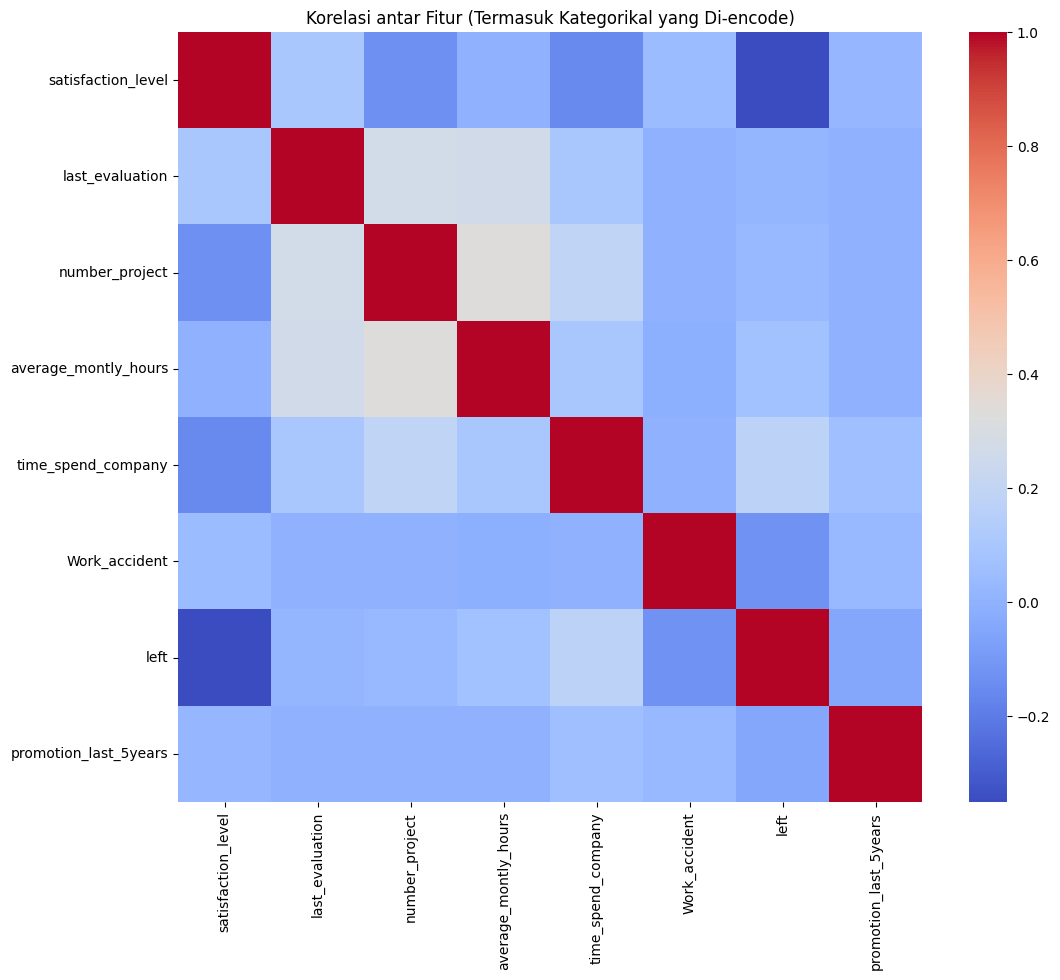

In [25]:
# Korelasi semua fitur numerik (termasuk yang telah di-encode)
plt.figure(figsize=(12, 10)) # Sesuaikan ukuran figure agar lebih mudah dibaca
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap='coolwarm') # Menggunakan 'data' dan tambahkan numeric_only=True
plt.title("Korelasi antar Fitur (Termasuk Kategorikal yang Di-encode)")
plt.show()

**Encoding Kolom Kategorikal**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 5️⃣ Tentukan Kolom Kategori dan Numerik (sesuai dataset HR_comma_sep.csv)
categorical_cols = ['Department', 'salary']
numeric_cols = [
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_montly_hours', 'time_spend_company', 'Work_accident',
    'promotion_last_5years'
]

# 6️⃣ Buat Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

**Split Data**

In [6]:
y = data['left']
X = data.drop('left', axis=1)

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True) # drop_first=True to avoid multicollinearity

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train (5 baris pertama):")
print(X_train[:5])
print("\nX_test (5 baris pertama):")
print(X_test[:5])
print("\ny_train (5 elemen pertama):")
print(y_train[:5])
print("\ny_test (5 elemen pertama):")
print(y_test[:5])


X_train (5 baris pertama):
       satisfaction_level  last_evaluation  number_project  \
2041                 0.98             0.91               4   
10444                0.63             0.89               3   
2030                 0.85             0.59               3   
11606                0.56             0.39               3   
2008                 0.50             0.75               6   

       average_montly_hours  time_spend_company  Work_accident  \
2041                    240                   3              0   
10444                   239                   3              0   
2030                    235                   3              0   
11606                   106                   8              0   
2008                    127                   3              0   

       promotion_last_5years  Department_RandD  Department_accounting  \
2041                       0             False                  False   
10444                      0             False          

**Standardisasi**

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Evaluasi Model**

**Pelatihan Model Regresi Logistik**

In [8]:
import pandas as pd

# Memuat ulang data awal dari CSV
data = pd.read_csv("/content/HR_comma_sep.csv")

# Menangani duplikat (seperti di langkah awal)
data.drop_duplicates(inplace=True)

print("Preview data awal setelah memuat ulang dan menghapus duplikat:")
display(data.head())

Preview data awal setelah memuat ulang dan menghapus duplikat:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Pelatihan dan Evaluasi Model Regresi Logistik**

**Penerapan Feature Engineering dan Encoding Fitur Kategori**

In [9]:
# ENCODE salary (ordinal)
salary_map = {'low': 0, 'medium': 1, 'high': 2}

if 'salary' in data.columns:
    data['salary'] = data['salary'].map(salary_map)
else:
    print("⚠ Kolom salary tidak ditemukan!")

# ONE-HOT ENCODING UNTUK DEPARTMENT
department_column = None

# Cari kolom terkait "department"
for col in data.columns:
    if col.lower() in ['department', 'departments', 'dept', 'sales']:
        department_column = col
        break

# Jika ketemu → lakukan one-hot encoding
if department_column:
    print(f"\nMelakukan one-hot encoding pada kolom: {department_column}")
    data = pd.get_dummies(data, columns=[department_column], drop_first=True)
else:
    print("\n⚠ Tidak ada kolom department/sales. Lewati encoding department.")

# --- OUTPUT AKHIR ---
print("\nData setelah feature engineering & encoding:")
display(data.head())

print("\nInfo kolom setelah transformasi:")
print(data.info())


Melakukan one-hot encoding pada kolom: Department

Data setelah feature engineering & encoding:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,True,False,False



Info kolom setelah transformasi:
<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_montly_hours    11991 non-null  int64  
 4   time_spend_company      11991 non-null  int64  
 5   Work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   salary                  11991 non-null  int64  
 9   Department_RandD        11991 non-null  bool   
 10  Department_accounting   11991 non-null  bool   
 11  Department_hr           11991 non-null  bool   
 12  Department_management   11991 non-null  bool   
 13  Department_marketing    11991 non-null  bool   
 14  Departmen

**Penskalaan Data**

In [10]:
from sklearn.model_selection import train_test_split

y = data['left']
X = data.drop('left', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData split into training and testing sets successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Data split into training and testing sets successfully!
X_train shape: (9592, 17)
X_test shape: (2399, 17)


In [11]:
# --- Menangani duplikat ---
data.drop_duplicates(inplace=True)

In [12]:
# --- Feature Engineering ---
# Workload Index
data['workload'] = data['number_project'] * data['average_montly_hours']
# Overtime indicator
data['overtime'] = (data['average_montly_hours'] > 200).astype(int)
# Company Stage
def company_stage(x):
    if x <= 2:
        return 0   # Baru
    elif x <= 5:
        return 1   # Menengah
    else:
        return 2   # Senior
data['company_stage'] = data['time_spend_company'].apply(company_stage)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_original = StandardScaler()
X_train_original_scaled = scaler_original.fit_transform(X_train)
X_test_original_scaled = scaler_original.transform(X_test)

print("Data asli berhasil diskalakan!")

Data asli berhasil diskalakan!


In [14]:
from sklearn.linear_model import LogisticRegression

logreg_original = LogisticRegression(random_state=42, solver='liblinear', max_iter=500)
logreg_original.fit(X_train_original_scaled, y_train)

print("Logistic Regression model berhasil dilatih!")

Logistic Regression model berhasil dilatih!


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log_original = logreg_original.predict(X_test_original_scaled)

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_original))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_original))


===== Logistic Regression =====
Accuracy: 0.8340975406419341

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.19      0.28       398

    accuracy                           0.83      2399
   macro avg       0.68      0.58      0.59      2399
weighted avg       0.80      0.83      0.80      2399


Confusion Matrix:
 [[1925   76]
 [ 322   76]]


**ROC Curve dan AUC Score**

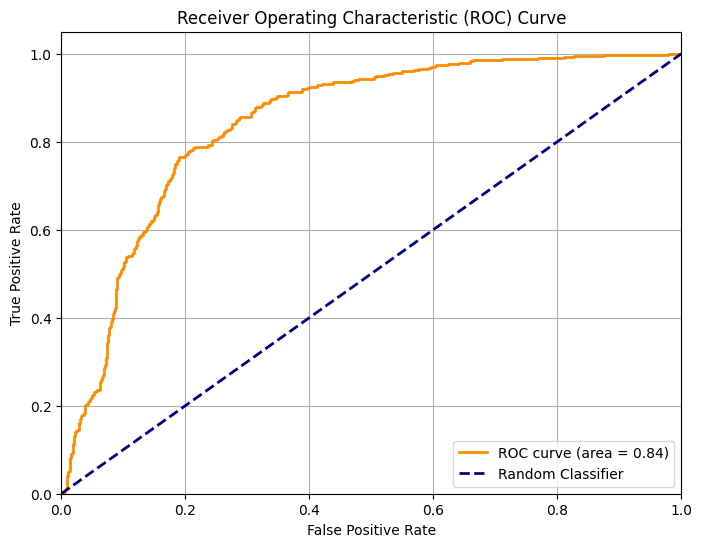

AUC Score: 0.84


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Dapatkan probabilitas prediksi untuk kelas positif (kelas 1)
y_pred_proba = logreg_original.predict_proba(X_test_original_scaled)[:, 1]

# Hitung False Positive Rate (FPR), True Positive Rate (TPR), dan Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Hitung Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.2f}")

**Koefisien Fitur Model Regresi Logistik**

In [17]:
import pandas as pd

# Dapatkan koefisien dari model
coefficients = logreg_original.coef_[0]
intercept = logreg_original.intercept_[0]

# Dapatkan nama fitur dari X_train
feature_names = X_train.columns

# Buat DataFrame untuk menampilkan koefisien
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Tambahkan intercept
coef_df.loc[len(coef_df)] = ['Intercept', intercept]

# Urutkan berdasarkan nilai absolut koefisien untuk melihat fitur paling berpengaruh
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Koefisien Model Regresi Logistik:")
display(coef_df)

Koefisien Model Regresi Logistik:


,Feature,Coefficient
17,Intercept,-2.080023
0,satisfaction_level,-0.923005
5,Work_accident,-0.495799
4,time_spend_company,0.423723
7,salary,-0.394586
2,number_project,-0.313157
3,average_montly_hours,0.199857
6,promotion_last_5years,-0.162590
1,last_evaluation,0.123616
8,Department_RandD,-0.094407


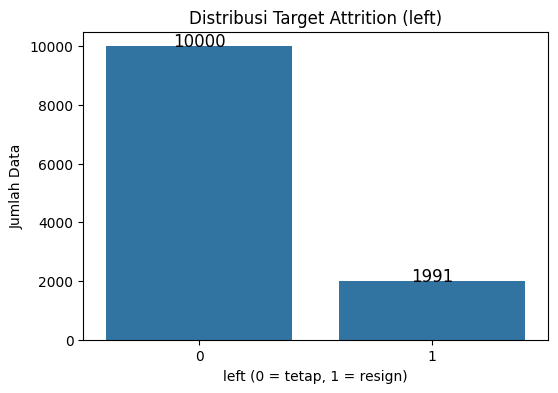

In [26]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)
plt.title("Distribusi Target Attrition (left)")
plt.xlabel("left (0 = tetap, 1 = resign)")
plt.ylabel("Jumlah Data")

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 2,
        f'{int(height)}',
        ha="center",
        fontsize=12,
        color="black"
    )

plt.show()

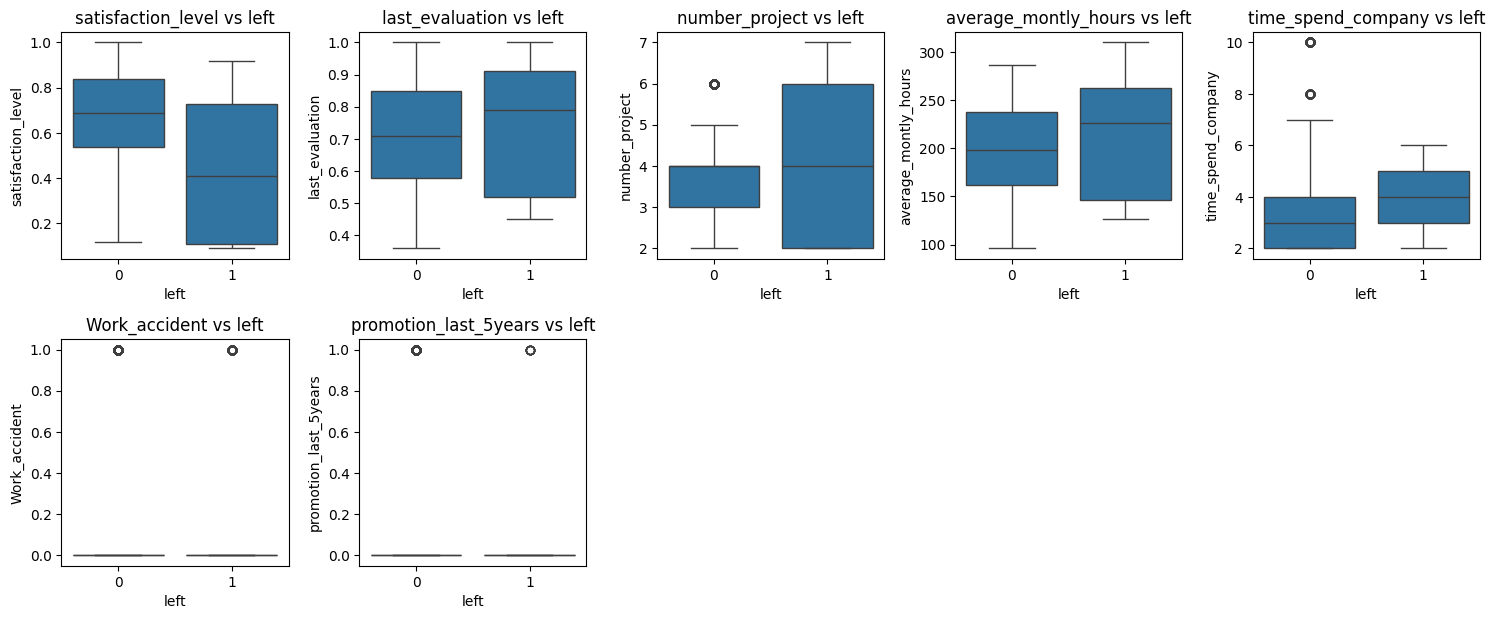

In [27]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('left')

plt.figure(figsize=(15,12))

for idx, col in enumerate(num_cols, 1):
    plt.subplot(4,5,idx)
    sns.boxplot(x=data['left'], y=data[col])
    plt.title(f"{col} vs left")
    plt.tight_layout()

Top 5 Fitur Paling Berpengaruh Terhadap Attrition (left):


,feature,correlation_with_left
0,satisfaction_level,-0.350558
1,time_spend_company,0.173295
2,Work_accident,-0.125436
3,average_montly_hours,0.070409
4,promotion_last_5years,-0.044657


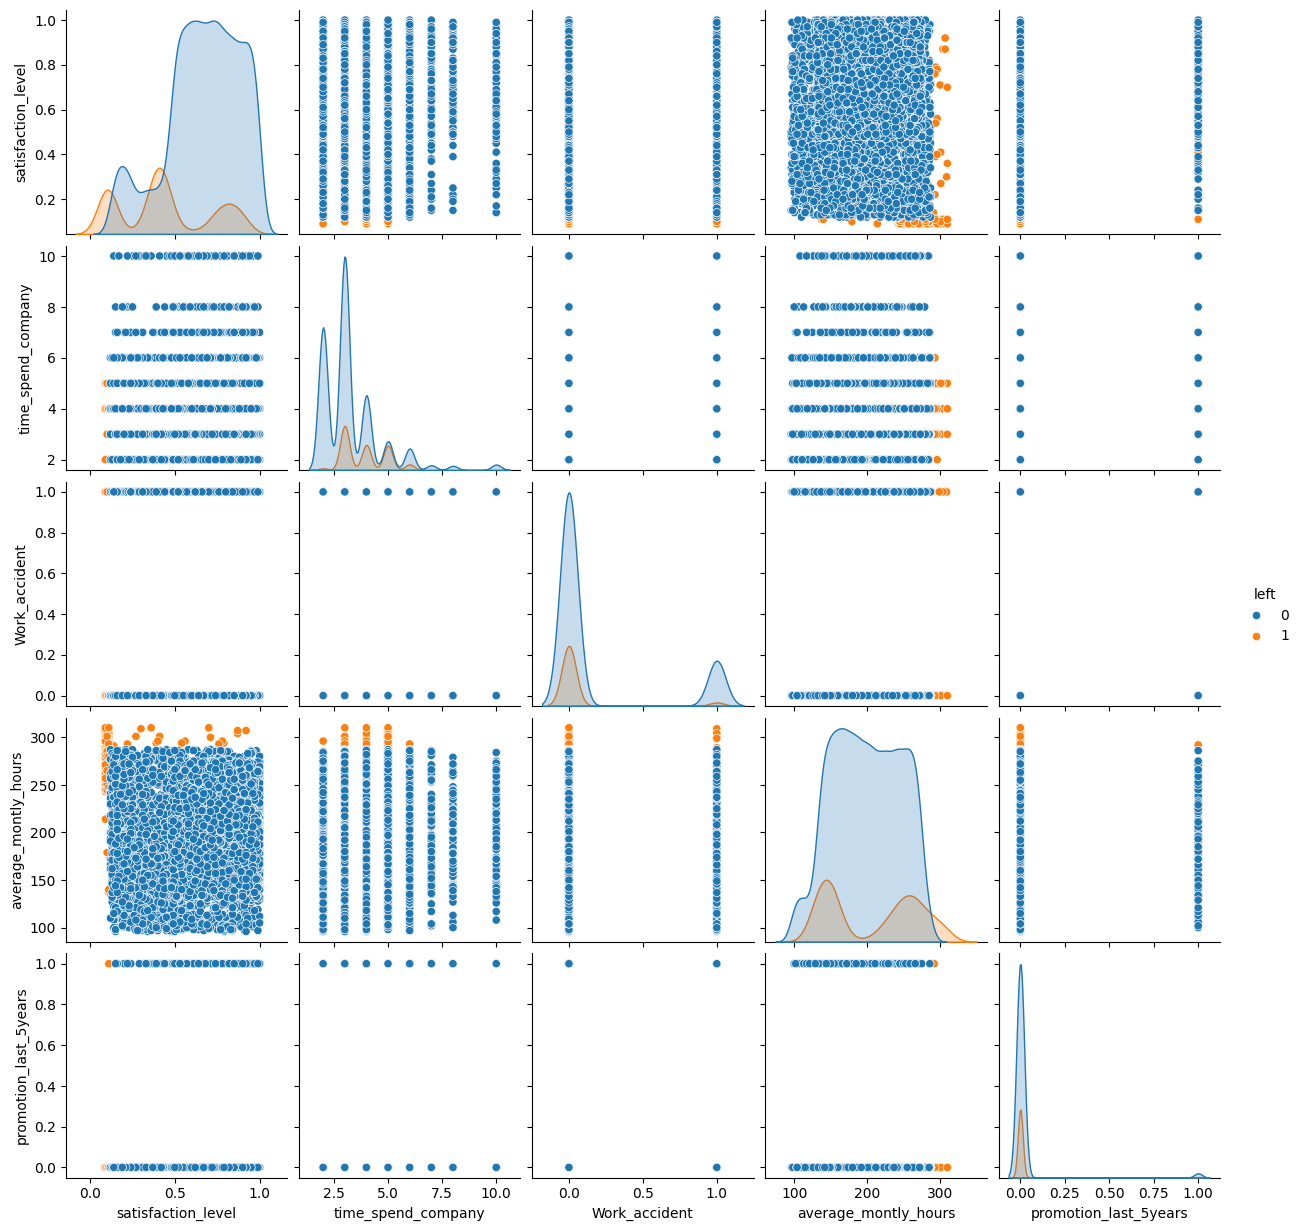

In [30]:
# Hitung korelasi dengan target (left)
# Tambahkan numeric_only=True untuk memastikan hanya kolom numerik yang digunakan
corr_target = data.corr(numeric_only=True)['left'].drop('left')

# Ambil 5 fitur dengan korelasi absolut terbaik
top5_corr = corr_target.abs().sort_values(ascending=False).head(5)
top5_features = top5_corr.index.tolist()

# Tabel ringkas
top5_table = pd.DataFrame({
    'feature': top5_features,
    'correlation_with_left': corr_target[top5_features].values
})

print("Top 5 Fitur Paling Berpengaruh Terhadap Attrition (left):")
display(top5_table)

# Pairplot dengan data (agar kolom cocok)
sns.pairplot(data[top5_features + ['left']], hue='left')